# Evalify Job Matching Custom Transformer V5 — Structured Features Training

Notebook ini adalah upgrade dari model V4.

Perbedaan utama V5:

```text
V4:
- text pair: resume + job text
- numeric features sederhana:
  skill count, skill overlap, lexical jaccard, title overlap, education, experience, word count, semantic proxy

V5:
- tetap memakai text pair seperti V4
- tetap mempertahankan numeric features V4
- menambahkan structured features dari hasil parsing:
  cv_skills, job_required_skills, tools, domain, education, years experience,
  project experience, responsibilities, seniority, certifications
- memakai taxonomy enriched untuk konsistensi extraction/normalization
```

File yang dipakai:

```text
augmented_training_role_balanced_1to1.csv
weak_same_role_negative_25pct_supplement.csv
cv_job_structured_features_normalized.csv
master_resume_job_taxonomy_global_enriched.json
```

Target label:

```text
source == "job_applicant_dataset"
→ Training Label = Best Match Revised

source selain "job_applicant_dataset"
→ Training Label = Best Match
```

Split data:

```text
Train : 70%
Val   : 15%
Test  : 15%
```

Split dilakukan berdasarkan `resume_group`, bukan random row biasa, supaya resume yang sama tidak bocor ke train dan test.

## 1. Optional Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Jalankan jika environment belum punya library ini.
# !pip install pandas numpy scikit-learn tensorflow joblib matplotlib

## 2. Import Library dan Global Config

In [8]:
import os
import re
import json
import html
import hashlib
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# =========================
# PROJECT DIRECTORY
# =========================
PROJECT_DIR = Path("Job-Matching_Supervised-Learning-v5")

# =========================
# DATA PATHS
# =========================
BASE_DATA_PATH = "augmented_training_role_balanced_1to1.csv"
WEAK_NEGATIVE_PATH = "weak_same_role_negative_25pct_supplement.csv"

STRUCTURED_FEATURES_PATH = "cv_job_structured_features_normalized.csv"
STRUCTURED_FEATURES_PATH_ALT = "cv_job_structured_features_normalized(1).csv"

TAXONOMY_PATH = "master_resume_job_taxonomy_global_enriched.json"

# =========================
# OUTPUT ARTIFACT
# =========================
ARTIFACT_DIR = Path("evalify_transformer_v5_structured_features_artifacts2")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "evalify_custom_transformer_job_matching_v5_structured_features.keras"
METADATA_PATH = ARTIFACT_DIR / "evalify_custom_transformer_v5_structured_features_metadata.json"
FEATURE_CONFIG_PATH = ARTIFACT_DIR / "feature_config_v5_structured_features.joblib"
TRAINING_REPORT_PATH = ARTIFACT_DIR / "training_report_v5_structured_features.json"

print("Project dir:", PROJECT_DIR)
print("Artifact dir:", ARTIFACT_DIR)

# =========================
# TRAINING CONFIG
# =========================
USE_SAMPLE = False          # ubah True jika ingin test cepat
SAMPLE_SIZE = 30000         # dipakai jika USE_SAMPLE=True

MAX_TOKENS = 30000
SEQUENCE_LENGTH = 256
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
DROPOUT_RATE = 0.15

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 2e-4

print("TensorFlow:", tf.__version__)
print("Artifact dir:", ARTIFACT_DIR)

Project dir: Job-Matching_Supervised-Learning-v5
Artifact dir: evalify_transformer_v5_structured_features_artifacts2
TensorFlow: 2.21.0
Artifact dir: evalify_transformer_v5_structured_features_artifacts2


## 3. Utility Function

In [9]:
def clean_text(text):
    text = "" if pd.isna(text) else str(text).lower()
    text = html.unescape(text).replace("\xa0", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9+#./()\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in", "is",
    "it", "its", "of", "on", "that", "the", "to", "was", "were", "will", "with", "you", "your",
    "or", "this", "these", "those", "their", "they", "we", "our", "into", "while", "also", "such",
    "role", "job", "candidate", "responsible", "requirements", "required", "skills", "experience"
}

def tokenize_for_overlap(text):
    tokens = re.findall(r"[a-z0-9+#.]+", clean_text(text))
    return {tok for tok in tokens if len(tok) > 2 and tok not in STOPWORDS}

def pipe_to_set(value):
    if pd.isna(value) or value is None:
        return set()
    return {str(x).strip().lower() for x in str(value).split("|") if str(x).strip()}

def set_to_pipe(values):
    return "|".join(sorted({str(x).strip().lower() for x in values if str(x).strip()}))

def safe_ratio(numerator, denominator):
    return float(numerator) / float(denominator) if denominator else 0.0

def jaccard_similarity(set_a, set_b):
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)

def make_resume_group(text):
    text = clean_text(text)
    return hashlib.md5(text.encode("utf-8")).hexdigest()

def normalize_role_light(role):
    return re.sub(r"\s+", " ", clean_text(role)).strip()

print("Utility functions ready.")

Utility functions ready.


## 4. Load Dataset Utama dan Structured Feature File

In [10]:
base_df = pd.read_csv(BASE_DATA_PATH)
weak_df = pd.read_csv(WEAK_NEGATIVE_PATH)

print("Base shape:", base_df.shape)
print("Weak negative shape:", weak_df.shape)

# Samakan kolom wajib.
required_main_columns = ["resume", "nama_role", "Job Description", "Best Match", "source", "pair_type", "role_group", "role_family"]

for df_name, temp_df in [("base_df", base_df), ("weak_df", weak_df)]:
    missing_cols = [col for col in required_main_columns if col not in temp_df.columns]
    if missing_cols:
        raise ValueError(f"{df_name} missing columns: {missing_cols}")

df_raw = pd.concat([base_df, weak_df], ignore_index=True).reset_index(drop=True)
df_raw["combined_row_id"] = np.arange(len(df_raw))

print("Combined raw shape:", df_raw.shape)
print("\nBest Match distribution:")
print(df_raw["Best Match"].value_counts(normalize=True).rename("ratio"))

print("\nSource distribution:")
print(df_raw["source"].value_counts().head(20))

structured_path = Path(STRUCTURED_FEATURES_PATH)
if not structured_path.exists():
    structured_path = Path(STRUCTURED_FEATURES_PATH_ALT)

if not structured_path.exists():
    raise FileNotFoundError(
        f"Structured feature file not found. Tried: {STRUCTURED_FEATURES_PATH} and {STRUCTURED_FEATURES_PATH_ALT}"
    )

structured_df = pd.read_csv(structured_path)

print("\nStructured features shape:", structured_df.shape)
print("Structured columns:", structured_df.columns.tolist())

if "combined_row_id" not in structured_df.columns:
    raise ValueError("Structured feature file must contain combined_row_id.")

# Ambil hanya kolom structured yang dibutuhkan.
structured_columns = [
    "combined_row_id",
    "cv_skills",
    "cv_education_level",
    "cv_years_experience",
    "cv_project_experience",
    "cv_work_experience_title",
    "cv_tools_technologies",
    "cv_certifications",
    "cv_target_role",
    "cv_domain_keywords",
    "job_required_skills",
    "job_required_education",
    "job_required_years_experience",
    "job_responsibilities",
    "job_required_tools",
    "job_domain",
    "job_seniority_level",
]

missing_structured_cols = [col for col in structured_columns if col not in structured_df.columns]
if missing_structured_cols:
    raise ValueError(f"Structured feature columns missing: {missing_structured_cols}")

structured_df = structured_df[structured_columns].copy()

df = df_raw.merge(
    structured_df,
    on="combined_row_id",
    how="left",
    validate="one_to_one"
)

print("\nMerged shape:", df.shape)

missing_rate = df[structured_columns[1:]].isna().mean().sort_values(ascending=False)
print("\nStructured missing rate:")
print(missing_rate)

display(df.head(3))

Base shape: (249354, 8)
Weak negative shape: (62339, 8)
Combined raw shape: (311693, 9)

Best Match distribution:
Best Match
0    0.600001
1    0.399999
Name: ratio, dtype: float64

Source distribution:
source
role_balancing_synthetic              107756
balanced_synthetic_negative            95385
weak_same_role_synthetic               62339
job_description_synthetic_existing     36213
job_applicant_dataset                  10000
Name: count, dtype: int64

Structured features shape: (311693, 26)
Structured columns: ['combined_row_id', 'input_dataset', 'resume_excerpt', 'nama_role', 'job_description_excerpt', 'Best Match', 'source', 'pair_type', 'role_group', 'role_family', 'cv_skills', 'cv_education_level', 'cv_years_experience', 'cv_project_experience', 'cv_work_experience_title', 'cv_tools_technologies', 'cv_certifications', 'cv_target_role', 'cv_domain_keywords', 'job_required_skills', 'job_required_education', 'job_required_years_experience', 'job_responsibilities', 'job_required_

,resume,nama_role,Job Description,Best Match,source,pair_type,role_group,role_family,combined_row_id,cv_skills,...,cv_certifications,cv_target_role,cv_domain_keywords,job_required_skills,job_required_education,job_required_years_experience,job_responsibilities,job_required_tools,job_domain,job_seniority_level
0,Professional Summary: Candidate with 4+ years ...,Short Term Temporary (STT) Information Technol...,This Short Term Temporary (STT) Information Te...,1,role_balancing_synthetic,synthetic_positive_fill,short term temporary stt information technolog...,operations,0,communication|documentation|training,...,NaN,Short Term Temporary (STT) Information Technol...,education_training,analytical thinking|planning|teamwork|training,NaN,NaN,communicate|report|support|train,NaN,education_training,NaN
1,Resume Summary: Motivated professional with ba...,Accounts Payable Clerk,The Accounts Payable Clerk position focuses on...,1,role_balancing_synthetic,synthetic_positive_fill,accounts payable clerk,general,1,accounting|audit|contract|finance|presentation...,...,NaN,Accounts Payable Clerk,finance_risk|legal_policy,accounting|analytical thinking|audit|contract|...,NaN,NaN,document|monitor,NaN,finance_risk|legal_policy,NaN
2,Professional Summary: Candidate with 1+ years ...,Sales Associates,The Sales Associates role focuses on deliverin...,0,balanced_synthetic_negative,balanced_negative_different_role,sales associates,sales_marketing,2,communication|compliance|documentation|legal|p...,...,NaN,Short-Term Consultant,business_operations|finance_risk|legal_policy,customer service|sales,associate,NaN,analyze|communicate|develop|support,NaN,sales_marketing,NaN


## 5. Load Enriched Taxonomy

In [11]:
taxonomy = json.loads(Path(TAXONOMY_PATH).read_text(encoding="utf-8"))

print("Taxonomy loaded:", TAXONOMY_PATH)
print("CV taxonomy keys:", taxonomy["cv_taxonomy"].keys())
print("Job taxonomy keys:", taxonomy["job_description_taxonomy"].keys())
print("Normalization entries:", len(taxonomy["normalization_dictionary"]))

Taxonomy loaded: master_resume_job_taxonomy_global_enriched.json
CV taxonomy keys: dict_keys(['skills', 'education_levels', 'years_of_experience_terms', 'project_experience_terms', 'work_experience_titles', 'tools_technologies', 'certifications', 'target_roles', 'domain_keywords', 'seniority_levels'])
Job taxonomy keys: dict_keys(['required_skills', 'required_education', 'required_years_experience_terms', 'responsibilities_keywords', 'required_tools', 'domains', 'seniority_levels'])
Normalization entries: 15552


## 6. Prepare Text Columns

In [12]:
df_model = df.copy()

df_model["Resume"] = df_model["resume"].fillna("").astype(str)
df_model["Job Roles"] = df_model["nama_role"].fillna("").astype(str)
df_model["Job Description"] = df_model["Job Description"].fillna("").astype(str)

df_model["resume_clean"] = df_model["Resume"].apply(clean_text)
df_model["job_text_clean"] = (
    df_model["Job Roles"].fillna("").astype(str) + " " + df_model["Job Description"].fillna("").astype(str)
).apply(clean_text)

df_model["resume_word_count"] = df_model["resume_clean"].str.split().apply(len).astype(np.float32)
df_model["job_word_count"] = df_model["job_text_clean"].str.split().apply(len).astype(np.float32)

print(df_model[["Resume", "Job Roles", "Job Description", "resume_clean", "job_text_clean"]].head(2).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Resume                                                    Job Roles                                                                                                                                                                                                                                                                                                                                                     

## 7. Build Numeric Features V4 + Structured Features V5

Fitur V4 lama tetap dipertahankan:

```text
resume_skill_count
job_skill_count
skill_match_count
skill_match_ratio
skill_coverage_resume_to_job
lexical_jaccard
job_title_similarity
role_keyword_overlap
education_match
experience_match
resume_word_count
job_word_count
semantic_proxy_score
```

V5 menambahkan fitur terstruktur dari hasil extraction:

```text
structured_cv_skill_count
structured_job_skill_count
structured_matched_skill_count
structured_missing_skill_count
structured_skill_match_ratio
structured_cv_tool_count
structured_job_tool_count
structured_matched_tool_count
structured_missing_tool_count
structured_tool_match_ratio
structured_domain_match_ratio
structured_project_match_ratio
structured_responsibility_overlap
structured_certification_match
structured_seniority_match
structured_match_score
```

In [13]:
education_rank = {
    "": -1,
    "no degree": 0,
    "high school": 1,
    "ged": 1,
    "vocational diploma": 2,
    "diploma": 2,
    "associate degree": 2,
    "bachelor": 3,
    "bachelor degree": 3,
    "bachelors degree": 3,
    "undergraduate degree": 3,
    "master": 4,
    "master degree": 4,
    "masters degree": 4,
    "mba": 4,
    "msc": 4,
    "ma": 4,
    "phd": 5,
    "doctorate": 5,
    "postdoctoral": 6,
}

seniority_rank = {
    "": -1,
    "intern": 0,
    "trainee": 0,
    "apprentice": 0,
    "entry level": 1,
    "junior": 1,
    "associate": 1,
    "mid level": 2,
    "intermediate": 2,
    "experienced": 2,
    "senior": 3,
    "staff": 3,
    "principal": 4,
    "lead": 4,
    "manager": 4,
    "senior manager": 5,
    "director": 5,
    "head": 5,
    "vp": 6,
    "vice president": 6,
    "chief": 6,
    "c level": 6,
    "executive": 6,
}

def education_match_from_terms(cv_education, job_education):
    cv_education = "" if pd.isna(cv_education) else str(cv_education).strip().lower()
    job_education = "" if pd.isna(job_education) else str(job_education).strip().lower()

    if not job_education:
        return 0.5

    if not cv_education:
        return 0.0

    cv_rank = education_rank.get(cv_education, -1)
    job_rank = education_rank.get(job_education, -1)

    if cv_rank < 0 or job_rank < 0:
        return 0.5

    if cv_rank >= job_rank:
        return 1.0

    if job_rank - cv_rank == 1:
        return 0.6

    return 0.0

def experience_match_from_years(cv_years, job_years):
    if pd.isna(job_years):
        return 0.5
    if pd.isna(cv_years):
        return 0.0

    cv_years = float(cv_years)
    job_years = float(job_years)

    if cv_years >= job_years:
        return 1.0

    if job_years <= 0:
        return 1.0

    return max(0.0, min(cv_years / job_years, 1.0))

def seniority_match_from_terms(cv_title, cv_target_role, job_seniority):
    # Jika job seniority kosong, beri nilai netral.
    job_seniority = "" if pd.isna(job_seniority) else str(job_seniority).strip().lower()

    if not job_seniority:
        return 0.5

    text = f"{cv_title} {cv_target_role}".lower()

    # Heuristic seniority from CV role/title.
    cv_seniority = ""
    if re.search(r"intern|internship|trainee|apprentice", text):
        cv_seniority = "intern"
    elif re.search(r"fresh graduate|entry level|entry-level|junior|associate", text):
        cv_seniority = "entry level"
    elif re.search(r"mid level|mid-level|intermediate|experienced", text):
        cv_seniority = "mid level"
    elif re.search(r"senior|sr", text):
        cv_seniority = "senior"
    elif re.search(r"lead|principal|manager|head|chief|director", text):
        cv_seniority = "lead"

    if not cv_seniority:
        return 0.0

    cv_rank = seniority_rank.get(cv_seniority, -1)
    job_rank = seniority_rank.get(job_seniority, -1)

    if cv_rank < 0 or job_rank < 0:
        return 0.5

    if cv_rank >= job_rank:
        return 1.0

    if job_rank - cv_rank == 1:
        return 0.6

    return 0.0

def compute_structured_features(row):
    cv_skills = pipe_to_set(row.get("cv_skills", ""))
    job_skills = pipe_to_set(row.get("job_required_skills", ""))
    cv_tools = pipe_to_set(row.get("cv_tools_technologies", ""))
    job_tools = pipe_to_set(row.get("job_required_tools", ""))
    cv_domains = pipe_to_set(row.get("cv_domain_keywords", ""))
    job_domains = pipe_to_set(row.get("job_domain", ""))
    cv_projects = pipe_to_set(row.get("cv_project_experience", ""))
    job_responsibilities = pipe_to_set(row.get("job_responsibilities", ""))
    cv_certs = pipe_to_set(row.get("cv_certifications", ""))

    matched_skills = cv_skills & job_skills
    matched_tools = cv_tools & job_tools
    matched_domains = cv_domains & job_domains
    project_overlap_set = (cv_projects | cv_domains) & (job_domains | job_responsibilities)

    structured_skill_match_ratio = safe_ratio(len(matched_skills), len(job_skills))
    structured_skill_coverage_cv_to_job = safe_ratio(len(matched_skills), len(cv_skills))
    structured_tool_match_ratio = safe_ratio(len(matched_tools), len(job_tools))
    structured_domain_match_ratio = safe_ratio(len(matched_domains), len(job_domains))
    structured_project_match_ratio = safe_ratio(len(project_overlap_set), len(job_domains | job_responsibilities))
    structured_responsibility_overlap = safe_ratio(len(cv_projects & job_responsibilities), len(job_responsibilities))

    structured_education_match = education_match_from_terms(
        row.get("cv_education_level", ""),
        row.get("job_required_education", "")
    )

    structured_experience_match = experience_match_from_years(
        row.get("cv_years_experience", np.nan),
        row.get("job_required_years_experience", np.nan)
    )

    structured_seniority_match = seniority_match_from_terms(
        row.get("cv_work_experience_title", ""),
        row.get("cv_target_role", ""),
        row.get("job_seniority_level", "")
    )

    # Certification default neutral if job does not define certs.
    structured_certification_match = 0.5

    structured_match_score = (
        0.35 * structured_skill_match_ratio
        + 0.15 * structured_tool_match_ratio
        + 0.15 * structured_domain_match_ratio
        + 0.10 * structured_experience_match
        + 0.08 * structured_education_match
        + 0.07 * structured_project_match_ratio
        + 0.05 * structured_seniority_match
        + 0.03 * structured_certification_match
        + 0.02 * structured_responsibility_overlap
    )

    return {
        "structured_cv_skill_count": len(cv_skills),
        "structured_job_skill_count": len(job_skills),
        "structured_matched_skill_count": len(matched_skills),
        "structured_missing_skill_count": max(len(job_skills - cv_skills), 0),
        "structured_skill_match_ratio": structured_skill_match_ratio,
        "structured_skill_coverage_cv_to_job": structured_skill_coverage_cv_to_job,

        "structured_cv_tool_count": len(cv_tools),
        "structured_job_tool_count": len(job_tools),
        "structured_matched_tool_count": len(matched_tools),
        "structured_missing_tool_count": max(len(job_tools - cv_tools), 0),
        "structured_tool_match_ratio": structured_tool_match_ratio,

        "structured_cv_domain_count": len(cv_domains),
        "structured_job_domain_count": len(job_domains),
        "structured_matched_domain_count": len(matched_domains),
        "structured_domain_match_ratio": structured_domain_match_ratio,

        "structured_project_match_ratio": structured_project_match_ratio,
        "structured_responsibility_overlap": structured_responsibility_overlap,
        "structured_education_match": structured_education_match,
        "structured_experience_match": structured_experience_match,
        "structured_seniority_match": structured_seniority_match,
        "structured_certification_match": structured_certification_match,
        "structured_match_score": structured_match_score,
    }

structured_feature_df = pd.DataFrame(
    [compute_structured_features(row) for _, row in df_model.iterrows()]
)

df_model = pd.concat([df_model.reset_index(drop=True), structured_feature_df], axis=1)

# V4 features from structured terms + text overlap.
df_model["resume_skill_count"] = df_model["structured_cv_skill_count"].astype(np.float32)
df_model["job_skill_count"] = df_model["structured_job_skill_count"].astype(np.float32)
df_model["skill_match_count"] = df_model["structured_matched_skill_count"].astype(np.float32)
df_model["skill_match_ratio"] = df_model["structured_skill_match_ratio"].astype(np.float32)
df_model["skill_coverage_resume_to_job"] = df_model["structured_skill_coverage_cv_to_job"].astype(np.float32)

lexical_rows = []
for row in df_model[["resume_clean", "job_text_clean", "Job Roles"]].itertuples(index=False):
    resume_tokens = tokenize_for_overlap(row.resume_clean)
    job_tokens = tokenize_for_overlap(row.job_text_clean)
    role_tokens = tokenize_for_overlap(row._2)

    lexical_rows.append({
        "lexical_jaccard": jaccard_similarity(resume_tokens, job_tokens),
        "job_title_similarity": safe_ratio(len(role_tokens & resume_tokens), len(role_tokens)),
        "role_keyword_overlap": safe_ratio(len(role_tokens & (resume_tokens | job_tokens)), len(role_tokens)),
    })

lexical_df = pd.DataFrame(lexical_rows)
df_model = pd.concat([df_model.reset_index(drop=True), lexical_df], axis=1)

df_model["education_match"] = df_model["structured_education_match"].astype(np.float32)
df_model["experience_match"] = df_model["structured_experience_match"].astype(np.float32)

df_model["semantic_proxy_score"] = (
    0.28 * df_model["skill_match_ratio"]
    + 0.22 * df_model["skill_coverage_resume_to_job"]
    + 0.18 * df_model["job_title_similarity"]
    + 0.14 * df_model["role_keyword_overlap"]
    + 0.10 * df_model["lexical_jaccard"]
    + 0.04 * df_model["education_match"]
    + 0.04 * df_model["experience_match"]
)

print("Feature dataframe shape:", df_model.shape)
display(df_model[[
    "resume_skill_count",
    "job_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "structured_tool_match_ratio",
    "structured_domain_match_ratio",
    "structured_match_score",
    "semantic_proxy_score",
]].head())

Feature dataframe shape: (311693, 64)


,resume_skill_count,job_skill_count,skill_match_count,skill_match_ratio,structured_tool_match_ratio,structured_domain_match_ratio,structured_match_score,semantic_proxy_score
0,3.0,4.0,1.0,0.250000,0.0,1.0,0.381500,0.520282
1,6.0,7.0,5.0,0.714286,0.0,1.0,0.565000,0.756970
2,5.0,2.0,0.0,0.000000,0.0,0.0,0.130000,0.180000
3,6.0,2.0,0.0,0.000000,0.0,0.5,0.216667,0.185000
4,5.0,2.0,1.0,0.500000,0.0,1.0,0.469000,0.365786


## 8. Build Training Label

In [14]:
job_applicant_mask = df_model["source"].eq("job_applicant_dataset")

if job_applicant_mask.any():
    q40 = df_model.loc[job_applicant_mask, "semantic_proxy_score"].quantile(0.40)
    q60 = df_model.loc[job_applicant_mask, "semantic_proxy_score"].quantile(0.60)
else:
    q40 = df_model["semantic_proxy_score"].quantile(0.40)
    q60 = df_model["semantic_proxy_score"].quantile(0.60)

df_model["Best Match Revised"] = (
    (df_model["semantic_proxy_score"] >= q60)
    | ((df_model["Best Match"] == 1) & (df_model["semantic_proxy_score"] >= q40))
).astype(int)

df_model["Training Label"] = np.where(
    df_model["source"].eq("job_applicant_dataset"),
    df_model["Best Match Revised"],
    df_model["Best Match"],
).astype(int)

TARGET_COLUMN = "Training Label"

print("Best Match distribution:")
print(df_model["Best Match"].value_counts(normalize=True).rename("ratio"))

print("\nBest Match Revised distribution on job_applicant_dataset:")
if job_applicant_mask.any():
    print(df_model.loc[job_applicant_mask, "Best Match Revised"].value_counts(normalize=True).rename("ratio"))
else:
    print("No job_applicant_dataset rows found.")

print("\nTraining Label distribution:")
print(df_model[TARGET_COLUMN].value_counts(normalize=True).rename("ratio"))

print("\nTraining Label by source:")
display(pd.crosstab(df_model["source"], df_model[TARGET_COLUMN], normalize="index"))

Best Match distribution:
Best Match
0    0.600001
1    0.399999
Name: ratio, dtype: float64

Best Match Revised distribution on job_applicant_dataset:
Best Match Revised
0    0.5034
1    0.4966
Name: ratio, dtype: float64

Training Label distribution:
Training Label
0    0.599628
1    0.400372
Name: ratio, dtype: float64

Training Label by source:


Training Label,0,1
source,,
balanced_synthetic_negative,1.000000,0.000000
job_applicant_dataset,0.503400,0.496600
job_description_synthetic_existing,0.666667,0.333333
role_balancing_synthetic,0.000000,1.000000
weak_same_role_synthetic,1.000000,0.000000


## 9. Numeric Feature List

In [15]:
V4_NUMERIC_FEATURES = [
    "resume_skill_count",
    "job_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "skill_coverage_resume_to_job",
    "lexical_jaccard",
    "job_title_similarity",
    "role_keyword_overlap",
    "education_match",
    "experience_match",
    "resume_word_count",
    "job_word_count",
    "semantic_proxy_score",
]

V5_STRUCTURED_NUMERIC_FEATURES = [
    "structured_cv_skill_count",
    "structured_job_skill_count",
    "structured_matched_skill_count",
    "structured_missing_skill_count",
    "structured_skill_match_ratio",
    "structured_skill_coverage_cv_to_job",

    "structured_cv_tool_count",
    "structured_job_tool_count",
    "structured_matched_tool_count",
    "structured_missing_tool_count",
    "structured_tool_match_ratio",

    "structured_cv_domain_count",
    "structured_job_domain_count",
    "structured_matched_domain_count",
    "structured_domain_match_ratio",

    "structured_project_match_ratio",
    "structured_responsibility_overlap",
    "structured_education_match",
    "structured_experience_match",
    "structured_seniority_match",
    "structured_certification_match",
    "structured_match_score",
]

NUMERIC_FEATURES = V4_NUMERIC_FEATURES + V5_STRUCTURED_NUMERIC_FEATURES

for col in NUMERIC_FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce").fillna(0.0).astype(np.float32)

print("Total numeric features:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)

print("\nNumeric dtypes:")
print(df_model[NUMERIC_FEATURES].dtypes)

Total numeric features: 35
['resume_skill_count', 'job_skill_count', 'skill_match_count', 'skill_match_ratio', 'skill_coverage_resume_to_job', 'lexical_jaccard', 'job_title_similarity', 'role_keyword_overlap', 'education_match', 'experience_match', 'resume_word_count', 'job_word_count', 'semantic_proxy_score', 'structured_cv_skill_count', 'structured_job_skill_count', 'structured_matched_skill_count', 'structured_missing_skill_count', 'structured_skill_match_ratio', 'structured_skill_coverage_cv_to_job', 'structured_cv_tool_count', 'structured_job_tool_count', 'structured_matched_tool_count', 'structured_missing_tool_count', 'structured_tool_match_ratio', 'structured_cv_domain_count', 'structured_job_domain_count', 'structured_matched_domain_count', 'structured_domain_match_ratio', 'structured_project_match_ratio', 'structured_responsibility_overlap', 'structured_education_match', 'structured_experience_match', 'structured_seniority_match', 'structured_certification_match', 'structured

## 10. Optional Sampling

In [16]:
if USE_SAMPLE:
    df_model = (
        df_model
        .groupby(TARGET_COLUMN, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=SEED))
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )
    print("Using sample:", df_model.shape)

print("Final dataset shape:", df_model.shape)
print(df_model[TARGET_COLUMN].value_counts())

Final dataset shape: (311693, 66)
Training Label
0    186900
1    124793
Name: count, dtype: int64


In [17]:
# =========================
# SAVE FINAL DATASET + INSPECTION
# =========================

# Simpan dataset final sebelum split dan sebelum normalisasi numeric features.
# Ini membuat file masih mudah dibaca karena nilainya belum berubah menjadi z-score.
FINAL_DATASET_PATH = ARTIFACT_DIR / "final_training_dataset_v5_structured_features.csv"

df_model.to_csv(FINAL_DATASET_PATH, index=False, encoding="utf-8")

print("Final dataset saved to:")
print(FINAL_DATASET_PATH)

print("\nFinal dataset shape:")
print(df_model.shape)

print("\nTarget distribution:")
print(df_model[TARGET_COLUMN].value_counts())

print("\nTarget distribution ratio:")
print(df_model[TARGET_COLUMN].value_counts(normalize=True))

print("\nTotal columns:")
print(len(df_model.columns))

print("\nColumn list:")
for i, col in enumerate(df_model.columns, start=1):
    print(f"{i:03d}. {col}")

# =========================
# DATASET INFO
# =========================

print("Dataset info:")
df_model.info(verbose=True, show_counts=True)

# =========================
# DATASET DESCRIBE
# =========================

print("Numeric describe:")
print(df_model.describe(include=[np.number]).T.to_string())

print("\nObject / categorical describe:")
print(df_model.describe(include=["object"]).T.to_string())

# =========================
# SHOW TOP 5 ROWS WITHOUT TRUNCATED TEXT
# =========================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 5000)
pd.set_option("display.max_rows", 20)

print("Top 5 rows:")
print(df_model.head(5).to_string(index=False))

Final dataset saved to:
evalify_transformer_v5_structured_features_artifacts2\final_training_dataset_v5_structured_features.csv

Final dataset shape:
(311693, 66)

Target distribution:
Training Label
0    186900
1    124793
Name: count, dtype: int64

Target distribution ratio:
Training Label
0    0.599628
1    0.400372
Name: proportion, dtype: float64

Total columns:
66

Column list:
001. resume
002. nama_role
003. Job Description
004. Best Match
005. source
006. pair_type
007. role_group
008. role_family
009. combined_row_id
010. cv_skills
011. cv_education_level
012. cv_years_experience
013. cv_project_experience
014. cv_work_experience_title
015. cv_tools_technologies
016. cv_certifications
017. cv_target_role
018. cv_domain_keywords
019. job_required_skills
020. job_required_education
021. job_required_years_experience
022. job_responsibilities
023. job_required_tools
024. job_domain
025. job_seniority_level
026. Resume
027. Job Roles
028. resume_clean
029. job_text_clean
030. resu

In [18]:
# =========================
# SHOW TOP 5 IMPORTANT COLUMNS ONLY
# =========================

important_columns = [
    "combined_row_id",
    "source",
    "pair_type",
    "role_group",
    "role_family",

    "Resume",
    "Job Roles",
    "Job Description",

    "Best Match",
    "Best Match Revised",
    "Training Label",

    "cv_skills",
    "cv_education_level",
    "cv_years_experience",
    "cv_project_experience",
    "cv_work_experience_title",
    "cv_tools_technologies",
    "cv_certifications",
    "cv_target_role",
    "cv_domain_keywords",

    "job_required_skills",
    "job_required_education",
    "job_required_years_experience",
    "job_responsibilities",
    "job_required_tools",
    "job_domain",
    "job_seniority_level",

    "resume_skill_count",
    "job_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "skill_coverage_resume_to_job",
    "lexical_jaccard",
    "job_title_similarity",
    "role_keyword_overlap",
    "education_match",
    "experience_match",
    "resume_word_count",
    "job_word_count",
    "semantic_proxy_score",

    "structured_skill_match_ratio",
    "structured_tool_match_ratio",
    "structured_domain_match_ratio",
    "structured_project_match_ratio",
    "structured_responsibility_overlap",
    "structured_education_match",
    "structured_experience_match",
    "structured_seniority_match",
    "structured_certification_match",
    "structured_match_score",
]

existing_important_columns = [
    col for col in important_columns
    if col in df_model.columns
]

print("Top 5 rows - important columns only:")
print(df_model[existing_important_columns].head(5).to_string(index=False))

Top 5 rows - important columns only:
 combined_row_id                      source                        pair_type                                                role_group     role_family                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Resume                                                   Job Roles                                                                                                                                            

In [20]:
# =========================
# SAVE UNIQUE JOB DESCRIPTION + ROLE DATASET
# =========================

# Pilih nama kolom role yang tersedia.
if "Job Roles" in df_model.columns:
    ROLE_COLUMN = "Job Roles"
elif "nama_role" in df_model.columns:
    ROLE_COLUMN = "nama_role"
else:
    raise ValueError("Tidak ditemukan kolom role. Pastikan ada kolom 'Job Roles' atau 'nama_role'.")

required_columns = [
    "Job Description",
    ROLE_COLUMN,
    "role_group",
    "role_family",
]

missing_columns = [
    col for col in required_columns
    if col not in df_model.columns
]

if missing_columns:
    raise ValueError(f"Kolom berikut tidak ditemukan di df_model: {missing_columns}")

unique_job_role_desc_df = df_model[required_columns].copy()

# Bersihkan value.
unique_job_role_desc_df["Job Description"] = (
    unique_job_role_desc_df["Job Description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

unique_job_role_desc_df[ROLE_COLUMN] = (
    unique_job_role_desc_df[ROLE_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
)

unique_job_role_desc_df["role_group"] = (
    unique_job_role_desc_df["role_group"]
    .fillna("")
    .astype(str)
    .str.strip()
)

unique_job_role_desc_df["role_family"] = (
    unique_job_role_desc_df["role_family"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Hapus baris kosong.
unique_job_role_desc_df = unique_job_role_desc_df[
    unique_job_role_desc_df["Job Description"].ne("")
    & unique_job_role_desc_df[ROLE_COLUMN].ne("")
].copy()

# Ambil unique berdasarkan kombinasi Job Description + Role.
unique_job_role_desc_df = (
    unique_job_role_desc_df
    .drop_duplicates(
        subset=["Job Description", ROLE_COLUMN],
        keep="first"
    )
    .reset_index(drop=True)
)

# Rename kolom agar rapi.
unique_job_role_desc_df = unique_job_role_desc_df.rename(columns={
    ROLE_COLUMN: "job_role",
    "Job Description": "job_description",
})

# Simpan ke artifact dir.
UNIQUE_JOB_ROLE_DESC_PATH = ARTIFACT_DIR / "unique_job_role_descriptions_v5.csv"

unique_job_role_desc_df.to_csv(
    UNIQUE_JOB_ROLE_DESC_PATH,
    index=False,
    encoding="utf-8"
)

print("Unique job role + description dataset saved to:")
print(UNIQUE_JOB_ROLE_DESC_PATH)

print("\nShape:")
print(unique_job_role_desc_df.shape)

print("\nTotal unique job descriptions:")
print(unique_job_role_desc_df["job_description"].nunique())

print("\nTotal unique job roles:")
print(unique_job_role_desc_df["job_role"].nunique())

print("\nTotal unique job role + description pairs:")
print(len(unique_job_role_desc_df))

print("\nColumns:")
for i, col in enumerate(unique_job_role_desc_df.columns, start=1):
    print(f"{i:03d}. {col}")

print("\nRole family distribution:")
print(unique_job_role_desc_df["role_family"].value_counts())

print("\nRole group total unique:")
print(unique_job_role_desc_df["role_group"].nunique())

Unique job role + description dataset saved to:
evalify_transformer_v5_structured_features_artifacts2\unique_job_role_descriptions_v5.csv

Shape:
(167178, 4)

Total unique job descriptions:
143036

Total unique job roles:
6075

Total unique job role + description pairs:
167178

Columns:
001. job_description
002. job_role
003. role_group
004. role_family

Role family distribution:
role_family
operations         46326
general            40978
tech               35638
finance            17470
sales_marketing    11982
legal               4778
design              3653
health              3586
education           2767
Name: count, dtype: int64

Role group total unique:
5898


In [21]:
# =========================
# INSPECT UNIQUE JOB ROLE + DESCRIPTION DATASET
# =========================

print("Info:")
unique_job_role_desc_df.info(verbose=True, show_counts=True)

print("\nDescribe object columns:")
print(unique_job_role_desc_df.describe(include=["object"]).T.to_string())

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 5000)
pd.set_option("display.max_rows", 20)

print("\nTop 5 unique job role + descriptions:")
print(unique_job_role_desc_df.head(5).to_string(index=False))

Info:
<class 'pandas.DataFrame'>
RangeIndex: 167178 entries, 0 to 167177
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   job_description  167178 non-null  str  
 1   job_role         167178 non-null  str  
 2   role_group       167178 non-null  str  
 3   role_family      167178 non-null  str  
dtypes: str(4)
memory usage: 104.4 MB

Describe object columns:
                  count  unique                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## 11. Group Split by Resume

In [12]:
df_model["resume_group"] = df_model["Resume"].apply(make_resume_group)

group_label = (
    df_model
    .groupby("resume_group")[TARGET_COLUMN]
    .mean()
    .reset_index()
)

group_label["group_strata"] = pd.cut(
    group_label[TARGET_COLUMN],
    bins=[-0.01, 0.25, 0.75, 1.01],
    labels=["mostly_negative", "mixed", "mostly_positive"]
)

def safe_group_train_test_split(groups_df, test_size, random_state):
    try:
        return train_test_split(
            groups_df["resume_group"],
            test_size=test_size,
            random_state=random_state,
            stratify=groups_df["group_strata"],
        )
    except ValueError:
        return train_test_split(
            groups_df["resume_group"],
            test_size=test_size,
            random_state=random_state,
            stratify=None,
        )

train_groups, temp_groups = safe_group_train_test_split(
    group_label,
    test_size=0.30,
    random_state=SEED,
)

temp_group_label = group_label[group_label["resume_group"].isin(temp_groups)].copy()

val_groups, test_groups = safe_group_train_test_split(
    temp_group_label,
    test_size=0.50,
    random_state=SEED,
)

train_df = df_model[df_model["resume_group"].isin(train_groups)].copy()
val_df = df_model[df_model["resume_group"].isin(val_groups)].copy()
test_df = df_model[df_model["resume_group"].isin(test_groups)].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTarget ratio train:")
print(train_df[TARGET_COLUMN].value_counts(normalize=True))

print("\nTarget ratio val:")
print(val_df[TARGET_COLUMN].value_counts(normalize=True))

print("\nTarget ratio test:")
print(test_df[TARGET_COLUMN].value_counts(normalize=True))

print("\nResume group overlap checks:")
print("train ∩ val :", len(set(train_df["resume_group"]) & set(val_df["resume_group"])))
print("train ∩ test:", len(set(train_df["resume_group"]) & set(test_df["resume_group"])))
print("val ∩ test  :", len(set(val_df["resume_group"]) & set(test_df["resume_group"])))

Train: (218400, 67)
Val  : (47074, 67)
Test : (46219, 67)

Target ratio train:
Training Label
0    0.599203
1    0.400797
Name: proportion, dtype: float64

Target ratio val:
Training Label
0    0.597888
1    0.402112
Name: proportion, dtype: float64

Target ratio test:
Training Label
0    0.60341
1    0.39659
Name: proportion, dtype: float64

Resume group overlap checks:
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


## 12. Normalize Numeric Features

In [13]:
feature_mean = train_df[NUMERIC_FEATURES].mean()
feature_std = train_df[NUMERIC_FEATURES].std().replace(0, 1.0)

def normalize_numeric_features(frame):
    frame = frame.copy()
    frame[NUMERIC_FEATURES] = ((frame[NUMERIC_FEATURES] - feature_mean) / feature_std).astype(np.float32)
    return frame

train_df = normalize_numeric_features(train_df)
val_df = normalize_numeric_features(val_df)
test_df = normalize_numeric_features(test_df)

print("Normalized train numeric dtypes:")
print(train_df[NUMERIC_FEATURES].dtypes)

Normalized train numeric dtypes:
resume_skill_count                     float32
job_skill_count                        float32
skill_match_count                      float32
skill_match_ratio                      float32
skill_coverage_resume_to_job           float32
lexical_jaccard                        float32
job_title_similarity                   float32
role_keyword_overlap                   float32
education_match                        float32
experience_match                       float32
resume_word_count                      float32
job_word_count                         float32
semantic_proxy_score                   float32
structured_cv_skill_count              float32
structured_job_skill_count             float32
structured_matched_skill_count         float32
structured_missing_skill_count         float32
structured_skill_match_ratio           float32
structured_skill_coverage_cv_to_job    float32
structured_cv_tool_count               float32
structured_job_tool_count  

## 13. TextVectorization

In [14]:
resume_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize=None,
    name="resume_text_vectorizer",
)

job_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize=None,
    name="job_text_vectorizer",
)

resume_vectorizer.adapt(train_df["resume_clean"].astype(str).values)
job_vectorizer.adapt(train_df["job_text_clean"].astype(str).values)

resume_vocab_size = len(resume_vectorizer.get_vocabulary())
job_vocab_size = len(job_vectorizer.get_vocabulary())

print("Resume vocab size:", resume_vocab_size)
print("Job vocab size:", job_vocab_size)

Resume vocab size: 10227
Job vocab size: 28772


## 14. TensorFlow Dataset

In [15]:
def make_tf_dataset(frame, shuffle=False, batch_size=BATCH_SIZE):
    inputs = {
        "resume_text": frame["resume_clean"].fillna("").astype(str).values,
        "job_text": frame["job_text_clean"].fillna("").astype(str).values,
        "numeric_features": frame[NUMERIC_FEATURES].to_numpy(dtype=np.float32),
    }

    labels = frame[TARGET_COLUMN].to_numpy(dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((inputs, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(frame), 10000), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_df, shuffle=True)
val_ds = make_tf_dataset(val_df, shuffle=False)
test_ds = make_tf_dataset(test_df, shuffle=False)

for batch_inputs, batch_labels in train_ds.take(1):
    print(batch_inputs.keys())
    print(batch_inputs["resume_text"].shape)
    print(batch_inputs["job_text"].shape)
    print(batch_inputs["numeric_features"].shape)
    print(batch_labels.shape)

dict_keys(['resume_text', 'job_text', 'numeric_features'])
(128,)
(128,)
(128, 35)
(128,)


## 15. Custom Layers dan Loss

In [16]:
@tf.keras.utils.register_keras_serializable(package="Evalify")
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True,
            name="token_embedding"
        )
        self.pos_emb = layers.Embedding(
            input_dim=maxlen,
            output_dim=embed_dim,
            name="position_embedding"
        )
        self.supports_masking = True

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(inputs)
        return token_embeddings + position_embeddings

    def compute_mask(self, inputs, mask=None):
        return self.token_emb.compute_mask(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({
            "maxlen": self.maxlen,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="Evalify")
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            name="multi_head_attention"
        )
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ], name="feed_forward_network")
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.supports_masking = True

    def call(self, inputs, training=False, mask=None):
        attention_mask = None
        if mask is not None:
            attention_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.bool)

        attention_output = self.att(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            training=training,
        )
        attention_output = self.dropout1(attention_output, training=training)
        out1 = self.layernorm1(inputs + attention_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def compute_mask(self, inputs, mask=None):
        return mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="Evalify")
class MaskedGlobalAveragePooling1D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is None:
            return tf.reduce_mean(inputs, axis=1)

        mask = tf.cast(mask, inputs.dtype)
        mask = tf.expand_dims(mask, axis=-1)
        summed = tf.reduce_sum(inputs * mask, axis=1)
        counts = tf.reduce_sum(mask, axis=1)
        return summed / tf.maximum(counts, tf.keras.backend.epsilon())

    def compute_mask(self, inputs, mask=None):
        return None


@tf.keras.utils.register_keras_serializable(package="Evalify")
class AbsoluteDifference(layers.Layer):
    def call(self, inputs):
        left, right = inputs
        return tf.abs(left - right)


@tf.keras.utils.register_keras_serializable(package="Evalify")
class BinaryFocalLossWithSmoothing(keras.losses.Loss):
    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        label_smoothing=0.0,
        name="binary_focal_loss_with_smoothing",
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_true = tf.reshape(y_true, tf.shape(y_pred))

        if self.label_smoothing > 0:
            y_true = y_true * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
        modulating_factor = tf.pow(1.0 - p_t, self.gamma)

        return tf.reduce_mean(alpha_factor * modulating_factor * bce)

    def get_config(self):
        config = super().get_config()
        config.update({
            "gamma": self.gamma,
            "alpha": self.alpha,
            "label_smoothing": self.label_smoothing,
        })
        return config

print("Custom layers ready.")

Custom layers ready.


## 16. Build Custom Transformer V5

In [17]:
def build_text_encoder(vectorizer, vocab_size, name_prefix):
    text_input = keras.Input(shape=(1,), dtype=tf.string, name=f"{name_prefix}_raw_text")

    x = vectorizer(text_input)
    x = TokenAndPositionEmbedding(
        maxlen=SEQUENCE_LENGTH,
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        name=f"{name_prefix}_token_position_embedding"
    )(x)

    x = TransformerEncoderBlock(
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout_rate=DROPOUT_RATE,
        name=f"{name_prefix}_transformer_block_1"
    )(x)

    x = TransformerEncoderBlock(
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout_rate=DROPOUT_RATE,
        name=f"{name_prefix}_transformer_block_2"
    )(x)

    x = MaskedGlobalAveragePooling1D(name=f"{name_prefix}_masked_pooling")(x)
    x = layers.Dense(128, activation="gelu", name=f"{name_prefix}_dense_projection")(x)
    x = layers.Dropout(DROPOUT_RATE, name=f"{name_prefix}_projection_dropout")(x)

    return keras.Model(text_input, x, name=f"{name_prefix}_encoder")

resume_encoder = build_text_encoder(resume_vectorizer, resume_vocab_size, "resume")
job_encoder = build_text_encoder(job_vectorizer, job_vocab_size, "job")

resume_text_input = keras.Input(shape=(1,), dtype=tf.string, name="resume_text")
job_text_input = keras.Input(shape=(1,), dtype=tf.string, name="job_text")
numeric_input = keras.Input(shape=(len(NUMERIC_FEATURES),), dtype=tf.float32, name="numeric_features")

resume_embedding = resume_encoder(resume_text_input)
job_embedding = job_encoder(job_text_input)

abs_diff = AbsoluteDifference(name="absolute_difference")([resume_embedding, job_embedding])
elementwise_product = layers.Multiply(name="elementwise_product")([resume_embedding, job_embedding])

numeric_branch = layers.Dense(128, activation="gelu", name="numeric_dense_1")(numeric_input)
numeric_branch = layers.BatchNormalization(name="numeric_batch_norm_1")(numeric_branch)
numeric_branch = layers.Dropout(DROPOUT_RATE, name="numeric_dropout_1")(numeric_branch)
numeric_branch = layers.Dense(64, activation="gelu", name="numeric_dense_2")(numeric_branch)

combined = layers.Concatenate(name="combined_features")([
    resume_embedding,
    job_embedding,
    abs_diff,
    elementwise_product,
    numeric_branch,
])

x = layers.Dense(256, activation="gelu", name="classifier_dense_1")(combined)
x = layers.BatchNormalization(name="classifier_batch_norm_1")(x)
x = layers.Dropout(DROPOUT_RATE, name="classifier_dropout_1")(x)

x = layers.Dense(128, activation="gelu", name="classifier_dense_2")(x)
x = layers.Dropout(DROPOUT_RATE, name="classifier_dropout_2")(x)

x = layers.Dense(64, activation="gelu", name="classifier_dense_3")(x)
output = layers.Dense(1, activation="sigmoid", name="match_probability")(x)

model = keras.Model(
    inputs={
        "resume_text": resume_text_input,
        "job_text": job_text_input,
        "numeric_features": numeric_input,
    },
    outputs=output,
    name="evalify_custom_transformer_job_matching_v5_structured_features",
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-4),
    loss=BinaryFocalLossWithSmoothing(gamma=2.0, alpha=0.35, label_smoothing=0.02),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(curve="PR", name="pr_auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

Model: "evalify_custom_transformer_job_matching_v5_structured_features"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_features    │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_1     │ (None, 128)       │      4,608 │ numeric_features… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resume_text         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_text            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_batch_norm… │ (None, 128)       │        512 │ numeric_dense_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resume_encoder      │ (None, 128)       │  2,018,816 │ resume_text[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_encoder         │ (None, 128)       │  4,392,576 │ job_text[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dropout_1   │ (None, 128)       │          0 │ numeric_batch_no… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 128)       │          0 │ resume_encoder[0… │
│ (AbsoluteDifferenc… │                   │            │ job_encoder[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elementwise_product │ (None, 128)       │          0 │ resume_encoder[0… │
│ (Multiply)          │                   │            │ job_encoder[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_2     │ (None, 64)        │      8,256 │ numeric_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 576)       │          0 │ resume_encoder[0… │
│ (Concatenate)       │                   │            │ job_encoder[0][0… │
│                     │                   │            │ absolute_differe… │
│                     │                   │            │ elementwise_prod… │
│                     │                   │            │ numeric_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense_1  │ (None, 256)       │    147,712 │ combined_feature… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_batch_n… │ (None, 256)       │      1,024 │ classifier_dense… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout… │ (None, 256)       │          0 │ classifier_batch… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense_2  │ (None, 128)       │     32,896 │ classifier_dropo

 Total params: 6,614,721 (25.23 MB)

 Trainable params: 6,613,953 (25.23 MB)

 Non-trainable params: 768 (3.00 KB)

## 17. Class Weight dan Callback

In [18]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df[TARGET_COLUMN].values,
)

class_weight = {
    0: float(weights[0]),
    1: float(weights[1]),
}

print("Class weight:", class_weight)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(ARTIFACT_DIR / "best_v5_structured_features_checkpoint.keras"),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

Class weight: {0: 0.8344413369400762, 1: 1.24751525121667}


## 18. Train Model

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9656 - loss: 0.0102 - pr_auc: 0.9934 - precision: 0.9764 - recall: 0.9525 - roc_auc: 0.9934
Epoch 1: val_pr_auc improved from None to 0.99891, saving model to /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/best_v5_structured_features_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/best_v5_structured_features_checkpoint.keras
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 662s 375ms/step - accuracy: 0.9835 - loss: 0.0054 - pr_auc: 0.9984 - precision: 0.9855 - recall: 0.9733 - roc_auc: 0.9989 - val_accuracy: 0.9871 - val_loss: 0.0045 - val_pr_auc: 0.9989 - val_precision: 0.9808 - val_recall: 0.9872 - val_roc_auc: 0.9993 - learning_rate: 2.0000e-04
Epoch 2/10
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9855 - loss: 0.0087 - pr_auc: 0.9985 - pr

## 19. Plot Training History

,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
4,0.993434,0.002299,0.999697,0.993466,0.990130,0.999798,0.992629,0.002605,0.999568,0.991275,0.990385,0.999733,0.00010
5,0.993819,0.002016,0.999777,0.994186,0.990369,0.999850,0.993840,0.002526,0.999631,0.992236,0.992445,0.999776,0.00010
6,0.994057,0.001775,0.999826,0.994790,0.990358,0.999880,0.974636,0.004739,0.999545,0.998258,0.938560,0.999682,0.00010
7,0.994560,0.001479,0.999877,0.996230,0.990175,0.999914,0.991524,0.002927,0.999449,0.995561,0.983306,0.999727,0.00005
8,0.995087,0.001298,0.999904,0.996931,0.990792,0.999936,0.993946,0.003853,0.998988,0.993855,0.991072,0.999593,0.00005


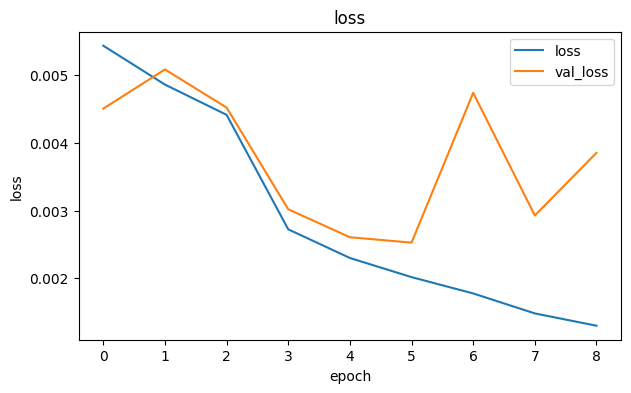

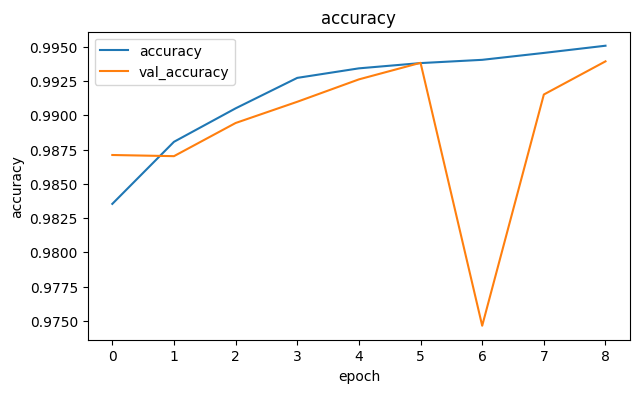

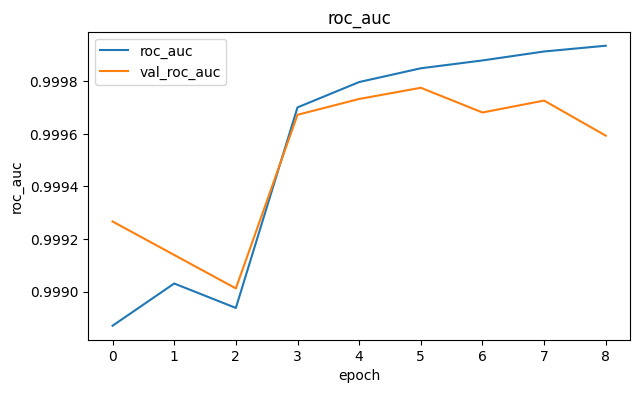

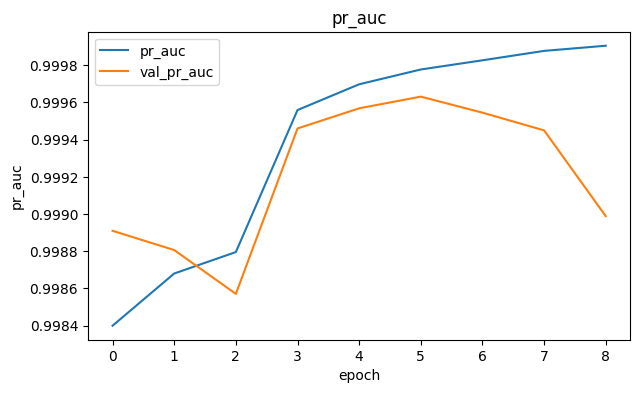

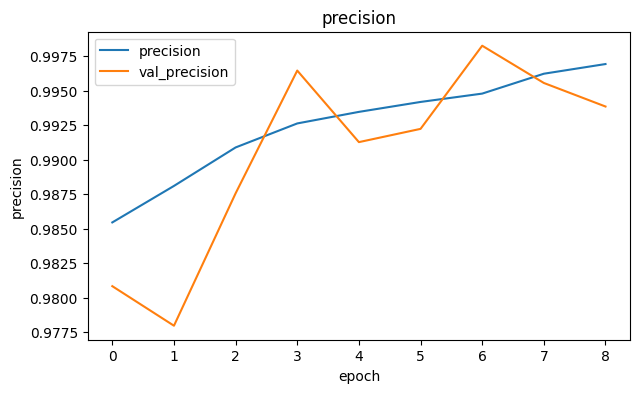

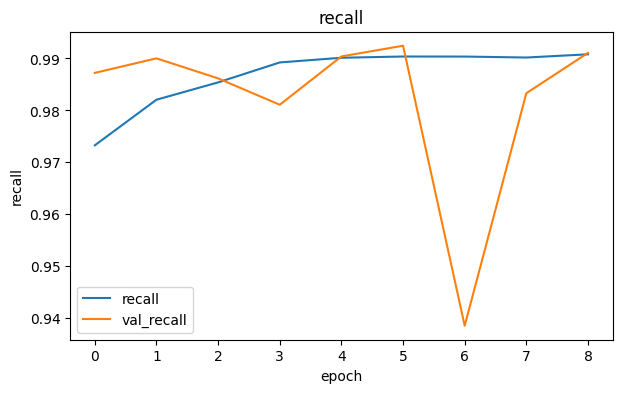

In [20]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

for metric in ["loss", "accuracy", "roc_auc", "pr_auc", "precision", "recall"]:
    if metric in history_df.columns and f"val_{metric}" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df[metric], label=metric)
        plt.plot(history_df[f"val_{metric}"], label=f"val_{metric}")
        plt.title(metric)
        plt.xlabel("epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.show()

## 20. Threshold Tuning on Validation Set

In [21]:
def predict_probabilities(frame, batch_size=BATCH_SIZE):
    ds = make_tf_dataset(frame, shuffle=False, batch_size=batch_size)
    return model.predict(ds, verbose=0).reshape(-1)

val_probs = predict_probabilities(val_df)
val_true = val_df[TARGET_COLUMN].values.astype(int)

threshold_candidates = np.linspace(0.05, 0.95, 91)
threshold_rows = []

for threshold in threshold_candidates:
    pred = (val_probs >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_true,
        pred,
        average="binary",
        zero_division=0,
    )
    acc = accuracy_score(val_true, pred)

    threshold_rows.append({
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])

print("Best threshold:", best_threshold)
display(threshold_df.sort_values("f1", ascending=False).head(10))

Best threshold: 0.48999999999999994


,threshold,accuracy,precision,recall,f1
44,0.49,0.994179,0.991827,0.993713,0.992769
43,0.48,0.994031,0.990840,0.994347,0.992591
42,0.47,0.993988,0.990168,0.994928,0.992543
45,0.50,0.993839,0.992236,0.992445,0.992341
41,0.46,0.993755,0.989185,0.995351,0.992258
46,0.51,0.993712,0.993015,0.991336,0.992175
47,0.52,0.993712,0.993485,0.990861,0.992171
40,0.45,0.993670,0.988208,0.996143,0.992160
39,0.44,0.993542,0.987795,0.996249,0.992004
37,0.42,0.993478,0.986773,0.997147,0.991933


## 21. Test Evaluation

In [22]:
test_probs = predict_probabilities(test_df)
test_true = test_df[TARGET_COLUMN].values.astype(int)
test_pred = (test_probs >= best_threshold).astype(int)

test_accuracy = accuracy_score(test_true, test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="binary",
    zero_division=0,
)

try:
    test_roc_auc = roc_auc_score(test_true, test_probs)
except ValueError:
    test_roc_auc = None

try:
    test_pr_auc = average_precision_score(test_true, test_probs)
except ValueError:
    test_pr_auc = None

metrics = {
    "threshold": best_threshold,
    "accuracy": float(test_accuracy),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1": float(test_f1),
    "roc_auc": None if test_roc_auc is None else float(test_roc_auc),
    "pr_auc": None if test_pr_auc is None else float(test_pr_auc),
}

print(json.dumps(metrics, indent=2))

print("\nClassification report:")
print(classification_report(test_true, test_pred, digits=4))

print("\nConfusion matrix:")
print(confusion_matrix(test_true, test_pred))

{
  "threshold": 0.48999999999999994,
  "accuracy": 0.9935091628983751,
  "precision": 0.9915485278080698,
  "recall": 0.992089470812875,
  "f1": 0.9918189255522225,
  "roc_auc": 0.9998157746269372,
  "pr_auc": 0.9997197493888537
}

Classification report:
              precision    recall  f1-score   support

           0     0.9948    0.9944    0.9946     27889
           1     0.9915    0.9921    0.9918     18330

    accuracy                         0.9935     46219
   macro avg     0.9932    0.9933    0.9932     46219
weighted avg     0.9935    0.9935    0.9935     46219


Confusion matrix:
[[27734   155]
 [  145 18185]]


## 22. Save Model, Feature Config, Metadata

In [25]:
def make_json_serializable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {
            str(make_json_serializable(k)): make_json_serializable(v)
            for k, v in obj.items()
        }
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    return obj

In [26]:
feature_config = {
    "version": "v5_structured_features",
    "numeric_features": NUMERIC_FEATURES,
    "v4_numeric_features": V4_NUMERIC_FEATURES,
    "v5_structured_numeric_features": V5_STRUCTURED_NUMERIC_FEATURES,
    "feature_mean": feature_mean.to_dict(),
    "feature_std": feature_std.to_dict(),
    "sequence_length": SEQUENCE_LENGTH,
    "max_tokens": MAX_TOKENS,
    "resume_vocab_size": resume_vocab_size,
    "job_vocab_size": job_vocab_size,
    "taxonomy_path": str(TAXONOMY_PATH),
    "target_column": TARGET_COLUMN,
    "target_policy": {
        "job_applicant_dataset": "Best Match Revised",
        "other_sources": "Best Match",
    },
}

feature_config = make_json_serializable(feature_config)
joblib.dump(feature_config, FEATURE_CONFIG_PATH)

metadata = {
    "model_name": model.name,
    "version": "v5_structured_features",
    "model_path": str(MODEL_PATH),
    "feature_config_path": str(FEATURE_CONFIG_PATH),
    "taxonomy_path": str(TAXONOMY_PATH),
    "base_data_path": str(BASE_DATA_PATH),
    "weak_negative_path": str(WEAK_NEGATIVE_PATH),
    "structured_features_path": str(structured_path),
    "target_column": TARGET_COLUMN,
    "target_policy": {
        "job_applicant_dataset": "Best Match Revised",
        "other_sources": "Best Match",
    },
    "numeric_features": NUMERIC_FEATURES,
    "best_threshold": float(best_threshold),
    "metrics": make_json_serializable(metrics),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "label_distribution": make_json_serializable(
        df_model[TARGET_COLUMN].value_counts().to_dict()
    ),
    "dataset_sources": make_json_serializable(
        df_model["source"].value_counts().to_dict()
    ),
    "notes": (
        "V5 model upgrades V4 by adding structured extraction features from "
        "cv_job_structured_features_normalized.csv and uses master_resume_job_taxonomy_global_enriched.json "
        "for extraction/normalization consistency."
    ),
}

metadata = make_json_serializable(metadata)

model.save(MODEL_PATH)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

training_report = {
    "metrics": make_json_serializable(metrics),
    "threshold_tuning_top10": make_json_serializable(
        threshold_df.sort_values("f1", ascending=False).head(10).to_dict(orient="records")
    ),
    "metadata": metadata,
}

with open(TRAINING_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(training_report, f, indent=2)

print("Model saved to:", MODEL_PATH)
print("Feature config saved to:", FEATURE_CONFIG_PATH)
print("Metadata saved to:", METADATA_PATH)
print("Training report saved to:", TRAINING_REPORT_PATH)

Model saved to: /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/evalify_custom_transformer_job_matching_v5_structured_features.keras
Feature config saved to: /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/feature_config_v5_structured_features.joblib
Metadata saved to: /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/evalify_custom_transformer_v5_structured_features_metadata.json
Training report saved to: /content/drive/MyDrive/Job-Matching_Supervised-Learning-v5/evalify_transformer_v5_structured_features_artifacts/training_report_v5_structured_features.json


## 23. Quick Inference Test

In [27]:
sample_rows = test_df.sample(5, random_state=SEED).copy()
sample_probs = predict_probabilities(sample_rows)
sample_rows["predicted_probability"] = sample_probs
sample_rows["predicted_label"] = (sample_rows["predicted_probability"] >= best_threshold).astype(int)

display(sample_rows[
    [
        "Resume",
        "Job Roles",
        "Best Match",
        "Best Match Revised",
        "Training Label",
        "predicted_probability",
        "predicted_label",
        "structured_match_score",
        "skill_match_ratio",
        "structured_tool_match_ratio",
        "structured_domain_match_ratio",
    ]
].head())

,Resume,Job Roles,Best Match,Best Match Revised,Training Label,predicted_probability,predicted_label,structured_match_score,skill_match_ratio,structured_tool_match_ratio,structured_domain_match_ratio
95337,Professional Summary: Candidate with 5+ years ...,Territory Sales Supervisor,0,0,0,9.566274e-07,0,-1.264618,-1.273660,-0.164956,-0.940779
228980,Profile: Detail-oriented applicant targeting a...,Implementation Unit Manager,0,0,0,2.713498e-07,0,0.819377,0.342169,-0.164956,1.277446
241718,Professional Summary: Candidate with 2+ years ...,.NET Web Developer,1,1,1,9.998618e-01,1,1.273951,0.342169,6.173808,0.538038
292396,Profile: Motivated beginner applying for Train...,Trainer,0,0,0,4.703870e-03,0,-1.264618,-1.273660,-0.164956,-0.940779
68776,Professional Summary: Candidate with 2+ years ...,Programme Office Manager,0,0,0,6.705368e-03,0,-1.466295,-1.273660,-0.164956,-0.940779


# Final Notes

V5 ini memakai `cv_job_structured_features_normalized.csv` sebagai **cached structured feature file**.

Artinya:
- training tidak perlu mengekstrak ulang semua CV/job dari nol,
- fitur lebih konsisten,
- model mendapat sinyal yang lebih kaya daripada V4.

Untuk inference V5 nanti, pipeline harus menghitung fitur yang sama:

```text
1. extract CV user memakai master_resume_job_taxonomy_global_enriched.json
2. gunakan job catalog yang sudah punya structured job features
3. hitung fitur V4 + V5 structured features
4. normalize numeric features memakai feature_config_v5_structured_features.joblib
5. predict dengan model V5
```